### STARVED V FED

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
from scipy.stats import wilcoxon


# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')


df['interaction_group'] = np.select(
    [
        (df['interaction_number'] == 1) & (df['interaction_frame'] < 1200),
        (df['interaction_number'] == 1) & (df['interaction_frame'] >= 1200),
    ],
    [
        'first',
        'not_viable_first',
    ],
    default='other'
)
df = df[df['interaction_group'] != 'not_viable_first'].copy()


df['role'] = df['track_id'].map({0: 'starved', 1: 'fed'})

df = df.sort_values(['file', 'track_id', 'rel_frame'])



metrics = ['speed_head', 'speed_body', 'speed_tail', 'heading_angle', 'heading_angle_change', 'approach_angle', 'approach_angle_head', 'cum_distance_start', 'cum_distance_0', 'distance_from_0', 'directional_alignment_cosine', 'track0_projection_onto_track1', 'head_distance']

file_larva_timecourse = (
    df.groupby(['file', 'track_id', 'role', 'interaction_group', 'rel_frame'])[metrics]
      .mean()
      .reset_index()
)

first_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'first']


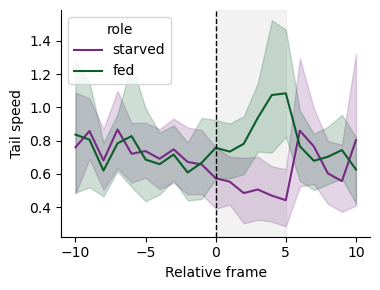

In [14]:
plt.figure(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='role',
    hue_order=['starved', 'fed'],
    palette={'starved': "#762A83", 'fed': '#0B5D2A'},
    errorbar=('ci', 95)
)

plt.axvspan(0, 5, color='0.9', alpha=0.5, zorder=0)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Relative frame')
plt.ylabel('Tail speed')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-starved/speed.pdf', format='pdf')
plt.show()


In [7]:
# Frames 1-5: average tail speed per larva, then paired fed vs starved test


speed_1_5 = (
    first_interaction[first_interaction['rel_frame'].between(1, 5)]
    .groupby(['file', 'role'])['speed_tail']
    .mean()
    .unstack()
)

display(speed_1_5)
print(speed_1_5.mean())

stat, p = wilcoxon(speed_1_5['starved'], speed_1_5['fed'])
print(f"Wilcoxon paired test, frames 1-5, starved vs fed: W={stat:.3g}, p={p:.3g}")


role,fed,starved
file,,
2026-04-28_12-24-02_td14.tracks.feather,1.525206,0.290243
2026-04-28_12-25-04_td15.tracks.feather,0.495252,0.548699
2026-04-28_12-26-23_td16.tracks.feather,0.858436,0.387449
2026-04-28_12-27-50_td17.tracks.feather,1.121139,0.242203
2026-05-12_14-59-35_td16.tracks.feather,0.600464,0.653691
2026-05-12_15-00-30_td15.tracks.feather,1.221485,0.809497
2026-05-18_12-10-36_td16.tracks.feather,1.225547,0.894397
2026-05-18_15-25-18_td9.tracks.feather,1.288038,1.087070
2026-06-05_12-18-12_td18.tracks.feather,0.561907,0.046267


role
fed        0.921975
starved    0.490958
dtype: float64
Wilcoxon paired test, frames 1-5, starved vs fed: W=3, p=0.00061


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_15189/2741461722.py:36: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


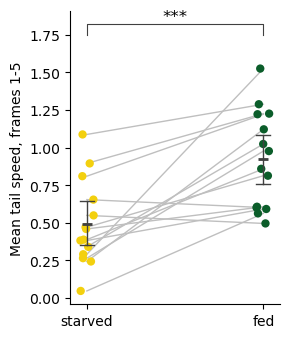

In [8]:
# Plot the values used in the frames 1-5 speed test
speed_1_5_plot = speed_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['starved', 'fed'],
    var_name='role',
    value_name='speed_tail'
)

if p < 0.001:
    stars = '***'
elif p < 0.01:
    stars = '**'
elif p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

for _, row in speed_1_5.iterrows():
    plt.plot([0, 1], [row['starved'], row['fed']], color='0.75', linewidth=1, zorder=1)

sns.stripplot(
    data=speed_1_5_plot,
    x='role',
    y='speed_tail',
    order=['starved', 'fed'],
    hue='role',
    palette={'starved': '#F3D00E', 'fed': '#0B5D2A'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=speed_1_5_plot,
    x='role',
    y='speed_tail',
    order=['starved', 'fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = speed_1_5_plot['speed_tail'].max()
ymin = speed_1_5_plot['speed_tail'].min()
y = ymax + (ymax - ymin) * 0.15
h = (ymax - ymin) * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean tail speed, frames 1-5')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-starved/speed_mean.pdf', format='pdf')
plt.show()


In [9]:
# Frames 1-5 after contact compared with frames -5 to -1 before contact, tail speed
pre_speed_1_5 = (
    first_interaction[first_interaction['rel_frame'].between(-5, -1)]
    .groupby(['file', 'role'])['speed_tail']
    .mean()
    .unstack()
)

post_speed_1_5 = (
    first_interaction[first_interaction['rel_frame'].between(1, 5)]
    .groupby(['file', 'role'])['speed_tail']
    .mean()
    .unstack()
)

change_speed_1_5 = post_speed_1_5 - pre_speed_1_5

display(pd.concat({'pre': pre_speed_1_5, 'post': post_speed_1_5, 'post_minus_pre': change_speed_1_5}, axis=1))
print('Mean pre:')
print(pre_speed_1_5.mean())
print('\nMean post:')
print(post_speed_1_5.mean())
print('\nMean post - pre:')
print(change_speed_1_5.mean())

stat, p = wilcoxon(pre_speed_1_5['starved'], post_speed_1_5['starved'])
print(f"Starved pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p:.3g}")

stat, p = wilcoxon(pre_speed_1_5['fed'], post_speed_1_5['fed'])
print(f"Fed pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p:.3g}")

stat, p = wilcoxon(change_speed_1_5['starved'], change_speed_1_5['fed'])
print(f"Change score, tail speed starved vs fed, frames 1-5: W={stat:.3g}, p={p:.3g}")


pre                post  \
role                                          fed   starved       fed   
file                                                                    
2026-04-28_12-24-02_td14.tracks.feather  0.486570  0.096660  1.525206   
2026-04-28_12-25-04_td15.tracks.feather  0.401260  0.539579  0.495252   
2026-04-28_12-26-23_td16.tracks.feather  0.492318  0.693008  0.858436   
2026-04-28_12-27-50_td17.tracks.feather  0.983625  0.698910  1.121139   
2026-05-12_14-59-35_td16.tracks.feather  0.502045  0.715882  0.600464   
2026-05-12_15-00-30_td15.tracks.feather  0.633517  0.807239  1.221485   
2026-05-18_12-10-36_td16.tracks.feather  1.177633  1.022499  1.225547   
2026-05-18_15-25-18_td9.tracks.feather   1.289985  0.959018  1.288038   
2026-06-05_12-18-12_td18.tracks.feather  0.966561  0.857040  0.561907   
2026-06-05_12-19-26_td19.tracks.feather  0.555894  1.031942  0.606293   
2026-06-05_12-20-32_td20.tracks.feather  0.435258  0.677814  0.591277   
2026-06-22_12-13-15_td16.tracks.feather  0.714328  0.415137  0.812628   
2026-06-22_12-14-29_td17.tracks.feather  0.130478  0.552669  1.023607   
2026-06-23_16-02-35_td17.tracks.feather  0.571404  0.743408  0.976376   

                                                  post_minus_pre            
role                                      starved            fed   starved  
file                                                                        
2026-04-28_12-24-02_td14.tracks.feather  0.290243       1.038636  0.193583  
2026-04-28_12-25-04_td15.tracks.feather  0.548699       0.093992  0.009120  
2026-04-28_12-26-23_td16.tracks.feather  0.387449       0.366118 -0.305558  
2026-04-28_12-27-50_td17.tracks.feather  0.242203       0.137514 -0.456707  
2026-05-12_14-59-35_td16.tracks.feather  0.653691       0.098418 -0.062191  
2026-05-12_15-00-30_td15.tracks.feather  0.809497       0.587968  0.002257  
2026-05-18_12-10-36_td16.tracks.feather  0.894397       0.047914 -0.128102  
2026-05-18_15-25-18_td9.tracks.feather   1.087070      -0.001947  0.128052  
2026-06-05_12-18-12_td18.tracks.feather  0.046267      -0.404654 -0.810773  
2026-06-05_12-19-26_td19.tracks.feather  0.458604       0.050399 -0.573337  
2026-06-05_12-20-32_td20.tracks.feather  0.381555       0.156019 -0.296259  
2026-06-22_12-13-15_td16.tracks.feather  0.469948       0.098300  0.054811  
2026-06-22_12-14-29_td17.tracks.feather  0.339571       0.893129 -0.213098  
2026-06-23_16-02-35_td17.tracks.feather  0.264213       0.404972 -0.479195

Mean pre:
role
fed        0.667205
starved    0.700772
dtype: float64

Mean post:
role
fed        0.921975
starved    0.490958
dtype: float64

Mean post - pre:
role
fed        0.254770
starved   -0.209814
dtype: float64
Starved pre vs post, tail speed frames 1-5: W=18, p=0.0295
Fed pre vs post, tail speed frames 1-5: W=11, p=0.00671
Change score, tail speed starved vs fed, frames 1-5: W=3, p=0.00061


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_15189/936634163.py:38: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


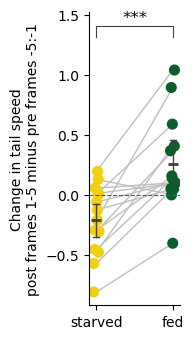

In [20]:
# Plot the values used in the frames 1-5 speed change-score test
_, change_p = wilcoxon(change_speed_1_5['starved'], change_speed_1_5['fed'])

change_speed_1_5_plot = change_speed_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['starved', 'fed'],
    var_name='role',
    value_name='speed_change'
)

if change_p < 0.001:
    stars = '***'
elif change_p < 0.01:
    stars = '**'
elif change_p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

for _, row in change_speed_1_5.iterrows():
    plt.plot([0, 1], [row['starved'], row['fed']], color='0.75', linewidth=1, zorder=1)

sns.stripplot(
    data=change_speed_1_5_plot,
    x='role',
    y='speed_change',
    order=['starved', 'fed'],
    hue='role',
    palette={'starved': '#F3D00E', 'fed': '#0B5D2A'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=change_speed_1_5_plot,
    x='role',
    y='speed_change',
    order=['starved', 'fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

plt.axhline(0, color='0.35', linewidth=0.8, linestyle='--')

ymax = change_speed_1_5_plot['speed_change'].max()
ymin = change_speed_1_5_plot['speed_change'].min()
y = ymax + (ymax - ymin) * 0.15
h = (ymax - ymin) * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Change in tail speed\npost frames 1-5 minus pre frames -5:-1')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-starved/speed_baseline_change.pdf', format='pdf')
plt.show()


In [11]:
# Test whether each condition changes from before to after contact, frames 1-5
stat, p_starved = wilcoxon(pre_speed_1_5['starved'], post_speed_1_5['starved'])
print(f"Starved pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_starved:.3g}")
print(f"Starved mean change: {change_speed_1_5['starved'].mean():.3g}")

stat, p_fed = wilcoxon(pre_speed_1_5['fed'], post_speed_1_5['fed'])
print(f"Fed pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_fed:.3g}")
print(f"Fed mean change: {change_speed_1_5['fed'].mean():.3g}")


Starved pre vs post, tail speed frames 1-5: W=18, p=0.0295
Starved mean change: -0.21
Fed pre vs post, tail speed frames 1-5: W=11, p=0.00671
Fed mean change: 0.255


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_15189/145643854.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_15189/145643854.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


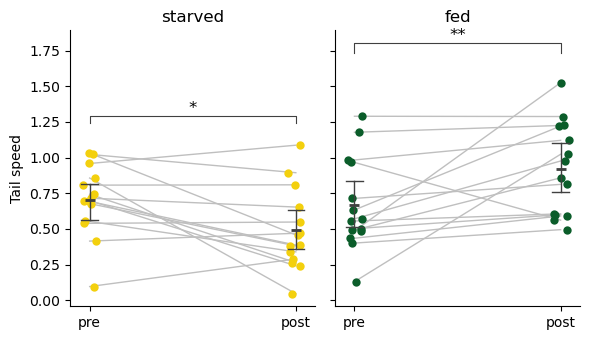

In [12]:
# Plot pre vs post tail speed within each condition, frames 1-5
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharey=True)

for ax, role, color, test_p in zip(
    axes,
    ['starved', 'fed'],
    ['#F3D00E', '#0B5D2A'],
    [p_starved, p_fed]
):
    plot_data = pd.DataFrame({
        'file': pre_speed_1_5.index,
        'pre': pre_speed_1_5[role],
        'post': post_speed_1_5[role]
    })
    long_plot_data = plot_data.melt(
        id_vars='file',
        value_vars=['pre', 'post'],
        var_name='time',
        value_name='speed_tail'
    )

    if test_p < 0.001:
        stars = '***'
    elif test_p < 0.01:
        stars = '**'
    elif test_p < 0.05:
        stars = '*'
    else:
        stars = 'ns'

    for _, row in plot_data.iterrows():
        ax.plot([0, 1], [row['pre'], row['post']], color='0.75', linewidth=1, zorder=1)

    sns.stripplot(
        data=long_plot_data,
        x='time',
        y='speed_tail',
        order=['pre', 'post'],
        color=color,
        size=6,
        jitter=0.04,
        ax=ax,
        zorder=2
    )

    sns.pointplot(
        data=long_plot_data,
        x='time',
        y='speed_tail',
        order=['pre', 'post'],
        errorbar=('ci', 95),
        color='0.25',
        markers='_',
        linestyles='none',
        capsize=0.08,
        err_kws={'linewidth': 1},
        join=False,
        ax=ax
    )

    ymax = long_plot_data['speed_tail'].max()
    ymin = long_plot_data['speed_tail'].min()
    y = ymax + (ymax - ymin) * 0.15
    h = (ymax - ymin) * 0.05
    ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
    ax.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

    ax.set_title(role)
    ax.set_xlabel('')
    ax.set_ylabel('Tail speed' if role == 'starved' else '')

sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-starved/speed_baseline_change_within_condition.pdf', format='pdf')
plt.show()


In [13]:
# Frames 1-10: average tail speed per larva, then paired fed vs starved test
speed_1_10 = (
    first_interaction[first_interaction['rel_frame'].between(1, 10)]
    .groupby(['file', 'role'])['speed_tail']
    .mean()
    .unstack()
)

display(speed_1_10)
print(speed_1_10.mean())

stat, p = wilcoxon(speed_1_10['starved'], speed_1_10['fed'])
print(f"Wilcoxon paired test, frames 1-10, starved vs fed: W={stat:.3g}, p={p:.3g}")


role,fed,starved
file,,
2026-04-28_12-24-02_td14.tracks.feather,1.073169,0.450044
2026-04-28_12-25-04_td15.tracks.feather,0.413210,0.471208
2026-04-28_12-26-23_td16.tracks.feather,0.863178,0.490750
2026-04-28_12-27-50_td17.tracks.feather,0.979272,0.495931
2026-05-12_14-59-35_td16.tracks.feather,0.591138,0.722465
2026-05-12_15-00-30_td15.tracks.feather,1.139358,0.821208
2026-05-18_12-10-36_td16.tracks.feather,0.982916,1.474709
2026-05-18_15-25-18_td9.tracks.feather,1.306459,1.117292
2026-06-05_12-18-12_td18.tracks.feather,0.597696,0.269797


role
fed        0.812703
starved    0.604102
dtype: float64
Wilcoxon paired test, frames 1-10, starved vs fed: W=16, p=0.0203


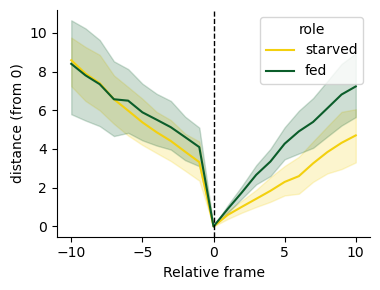

In [14]:
plt.figure(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='role',
    hue_order=['starved', 'fed'],
    palette={'starved': '#F3D00E', 'fed': '#0B5D2A'},
    errorbar=('ci', 95)
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Relative frame')
plt.ylabel('distance (from 0)')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-starved/distance_from_0.pdf', format='pdf')
plt.show()


In [15]:
# Frames 1-5: average distance_from_0 per larva, then paired fed vs starved test
distance_1_5 = (
    first_interaction[first_interaction['rel_frame'].between(1, 5)]
    .groupby(['file', 'role'])['distance_from_0']
    .mean()
    .unstack()
)

display(distance_1_5)
print(distance_1_5.mean())

stat, p = wilcoxon(distance_1_5['starved'], distance_1_5['fed'])
print(f"Wilcoxon paired test, distance_from_0 frames 1-5, starved vs fed: W={stat:.3g}, p={p:.3g}")


role,fed,starved
file,,
2026-04-28_12-24-02_td14.tracks.feather,1.877705,1.655670
2026-04-28_12-25-04_td15.tracks.feather,1.524979,0.954419
2026-04-28_12-26-23_td16.tracks.feather,2.707751,1.288245
2026-04-28_12-27-50_td17.tracks.feather,3.750333,1.181094
2026-05-12_14-59-35_td16.tracks.feather,1.717969,1.869948
2026-05-12_15-00-30_td15.tracks.feather,3.490859,2.515322
2026-05-18_12-10-36_td16.tracks.feather,3.502940,1.317280
2026-05-18_15-25-18_td9.tracks.feather,4.270193,3.631985
2026-06-05_12-18-12_td18.tracks.feather,1.279866,0.055851


role
fed        2.590244
starved    1.434539
dtype: float64
Wilcoxon paired test, distance_from_0 frames 1-5, starved vs fed: W=1, p=0.000244


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_15189/2677357591.py:38: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


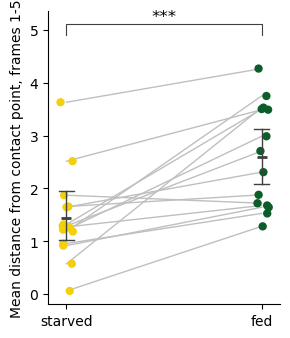

In [16]:
# Plot the values used in the frames 1-5 distance_from_0 test
_, distance_p = wilcoxon(distance_1_5['starved'], distance_1_5['fed'])

distance_1_5_plot = distance_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['starved', 'fed'],
    var_name='role',
    value_name='distance_from_0'
)

if distance_p < 0.001:
    stars = '***'
elif distance_p < 0.01:
    stars = '**'
elif distance_p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

for _, row in distance_1_5.iterrows():
    plt.plot([0, 1], [row['starved'], row['fed']], color='0.75', linewidth=1, zorder=1)

sns.stripplot(
    data=distance_1_5_plot,
    x='role',
    y='distance_from_0',
    order=['starved', 'fed'],
    hue='role',
    palette={'starved': '#F3D00E', 'fed': '#0B5D2A'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=distance_1_5_plot,
    x='role',
    y='distance_from_0',
    order=['starved', 'fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = distance_1_5_plot['distance_from_0'].max()
ymin = distance_1_5_plot['distance_from_0'].min()
y = ymax + (ymax - ymin) * 0.15
h = (ymax - ymin) * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean distance from contact point, frames 1-5')
sns.despine()
plt.tight_layout()
plt.show()


role,fed,starved
file,,
2026-04-28_12-24-02_td14.tracks.feather,3.510850,3.491419
2026-04-28_12-25-04_td15.tracks.feather,2.407758,1.808131
2026-04-28_12-26-23_td16.tracks.feather,4.879938,2.412328
2026-04-28_12-27-50_td17.tracks.feather,5.827089,2.314515
2026-05-12_14-59-35_td16.tracks.feather,3.130965,2.866010
2026-05-12_15-00-30_td15.tracks.feather,6.354801,4.427833
2026-05-18_12-10-36_td16.tracks.feather,5.869462,2.993489
2026-05-18_15-25-18_td9.tracks.feather,7.531606,6.537786
2026-06-05_12-18-12_td18.tracks.feather,2.613875,0.523541


role
fed        4.340504
starved    2.588420
dtype: float64
Wilcoxon paired test, distance_from_0 frames 1-10, starved vs fed: W=0, p=0.000122


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_15189/955998265.py:50: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


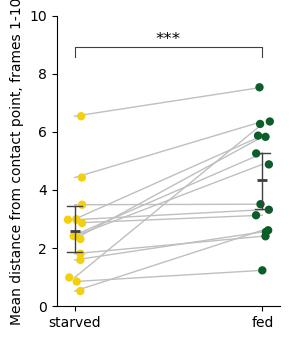

In [21]:
# Frames 1-10: average distance_from_0 per larva, then paired fed vs starved test
distance_1_10 = (
    first_interaction[first_interaction['rel_frame'].between(1, 10)]
    .groupby(['file', 'role'])['distance_from_0']
    .mean()
    .unstack()
)

display(distance_1_10)
print(distance_1_10.mean())

stat, p = wilcoxon(distance_1_10['starved'], distance_1_10['fed'])
print(f"Wilcoxon paired test, distance_from_0 frames 1-10, starved vs fed: W={stat:.3g}, p={p:.3g}")

# Plot the values used in the frames 1-10 distance_from_0 test
distance_1_10_plot = distance_1_10.reset_index().melt(
    id_vars='file',
    value_vars=['starved', 'fed'],
    var_name='role',
    value_name='distance_from_0'
)

if p < 0.001:
    stars = '***'
elif p < 0.01:
    stars = '**'
elif p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

for _, row in distance_1_10.iterrows():
    plt.plot([0, 1], [row['starved'], row['fed']], color='0.75', linewidth=1, zorder=1)

sns.stripplot(
    data=distance_1_10_plot,
    x='role',
    y='distance_from_0',
    order=['starved', 'fed'],
    hue='role',
    palette={'starved': '#F3D00E', 'fed': '#0B5D2A'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=distance_1_10_plot,
    x='role',
    y='distance_from_0',
    order=['starved', 'fed'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = distance_1_10_plot['distance_from_0'].max()
ymin = distance_1_10_plot['distance_from_0'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean distance from contact point, frames 1-10')
plt.ylim(0, 10)
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-starved/distance_from_0_mean.pdf', format='pdf')
plt.show()
